# Task 1: Term Deposit Subscription Prediction
## Bank Marketing Campaign Analysis
**DevelopersHub Corporation — Data Science & Analytics Advanced Internship**

---

## Problem Statement & Objective

A Portuguese bank ran a series of telemarketing campaigns to get customers to subscribe to **term deposits** — a fixed-interest savings product. The challenge is to **predict which customers are likely to subscribe** based on demographic, financial, and campaign-related features.

### Business Goal
Build a binary classifier that distinguishes subscribers (`yes`) from non-subscribers (`no`) so the bank can **target the right customers**, reduce campaign costs, and improve conversion rates.

### Dataset Overview
| Property | Value |
|---|---|
| Rows | 5,000 |
| Features | 16 |
| Target | `y` — subscribed? (yes/no) |
| Class imbalance | 9.3:1 (no:yes) |
| Positive rate | 9.7% |

### Skills Demonstrated
- Classification Modeling (Logistic Regression, Random Forest)
- Feature Encoding (One-Hot, Binary)
- Model Interpretability — SHAP-style Feature Attribution (XAI)
- Customer Behaviour Analysis


## Step 1: Imports & Setup

In [ ]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay, classification_report,
    f1_score, roc_auc_score, roc_curve, auc,
    precision_recall_curve, average_precision_score
)

import os
os.makedirs('plots', exist_ok=True)

# Colour palette
C_NO, C_YES, C_LR, C_RF = '#e74c3c', '#2ecc71', '#3498db', '#e67e22'

plt.rcParams.update({'figure.facecolor':'white','axes.facecolor':'white',
                     'axes.grid':True,'grid.alpha':0.3,'font.size':11})

print('All libraries loaded ')

All libraries loaded ✓


## Step 2: Dataset Description & Loading

### Feature Dictionary

| Feature | Type | Description |
|---|---|---|
| `age` | Numeric | Customer age |
| `job` | Categorical | Type of job |
| `marital` | Categorical | Marital status |
| `education` | Categorical | Education level |
| `default` | Binary | Has credit in default? |
| `balance` | Numeric | Average yearly balance (€) |
| `housing` | Binary | Has housing loan? |
| `loan` | Binary | Has personal loan? |
| `contact` | Categorical | Contact communication type |
| `day` / `month` | Numeric/Cat | Last contact day/month |
| `duration` | Numeric | Last contact duration (seconds) |
| `campaign` | Numeric | Number of contacts this campaign |
| `pdays` | Numeric | Days since last contact (-1 = never) |
| `previous` | Numeric | Contacts before this campaign |
| `poutcome` | Categorical | Outcome of previous campaign |
| **`y`** | **Target** | **Subscribed to term deposit?** |


In [ ]:
np.random.seed(42)
N = 5_000

# --- Numeric features ---
age      = np.random.randint(18, 75, N)
duration = np.abs(np.random.normal(280, 200, N)).astype(int).clip(0, 1200)
balance  = np.random.normal(1_500, 3_000, N).astype(int).clip(-10_000, 20_000)
campaign = np.random.randint(1, 25, N)
pdays    = np.where(np.random.rand(N) < 0.75, -1, np.random.randint(1, 360, N))
previous = np.random.randint(0, 8, N)
day      = np.random.randint(1, 31, N)

# --- Categorical features ---
JOBS      = ['admin.','blue-collar','entrepreneur','housemaid','management',
             'retired','self-employed','services','student','technician','unemployed','unknown']
MONTHS    = ['jan','feb','mar','apr','may','jun','jul','aug','sep','oct','nov','dec']
POUTCOMES = ['failure','other','success','unknown']

job       = np.random.choice(JOBS, N)
month     = np.random.choice(MONTHS, N)
poutcome  = np.random.choice(POUTCOMES, N)
education = np.random.choice(['primary','secondary','tertiary','unknown'], N)
marital   = np.random.choice(['divorced','married','single'], N)
contact   = np.random.choice(['cellular','telephone','unknown'], N)
default   = np.random.choice([0,1], N, p=[0.98, 0.02])
housing   = np.random.choice([0,1], N, p=[0.44, 0.56])
loan      = np.random.choice([0,1], N, p=[0.84, 0.16])

# --- Target with realistic signal ---
logit = (
    -3.8
    + 0.005  * duration
    + 0.0002 * np.clip(balance, 0, None)
    - 0.12   * campaign
    + 0.60   * (poutcome == 'success').astype(float)
    + 0.35   * (contact  == 'cellular').astype(float)
    + 0.25   * (job == 'student').astype(float)
    + 0.25   * (job == 'retired').astype(float)
    - 0.30   * housing
    - 0.20   * loan
    - 0.20   * default
    + 0.003  * np.where(pdays > 0, pdays, 0)
    + 0.05   * previous
    + 0.008  * np.clip(age - 40, 0, None)
)
prob = 1 / (1 + np.exp(-logit))
y    = (np.random.rand(N) < prob).astype(int)

df = pd.DataFrame({
    'age':age,'job':job,'marital':marital,'education':education,
    'default':default,'balance':balance,'housing':housing,'loan':loan,
    'contact':contact,'day':day,'month':month,'duration':duration,
    'campaign':campaign,'pdays':pdays,'previous':previous,
    'poutcome':poutcome,'y':y
})

print(f'Dataset shape     : {df.shape}')
print(f'Positive rate     : {y.mean():.3f}')
print(f'Imbalance ratio   : {(y==0).sum()/(y==1).sum():.1f}:1')
df.head()

Dataset shape     : (5000, 17)
Positive rate     : 0.097
Imbalance ratio   : 9.3:1


In [ ]:
# Data types and null check
info = pd.DataFrame({'dtype': df.dtypes, 'null_count': df.isnull().sum(),
                     'null_pct': (df.isnull().sum()/len(df)*100).round(2)})
print(info.to_string())

age          int64    0    0.00
job          str      0    0.00
marital      str      0    0.00
education    str      0    0.00
default      int64    0    0.00
balance      int64    0    0.00
housing      int64    0    0.00
loan         int64    0    0.00
contact      str      0    0.00
day          int64    0    0.00
month        str      0    0.00
duration     int64    0    0.00
campaign     int64    0    0.00
pdays        int64    0    0.00
previous     int64    0    0.00
poutcome     str      0    0.00
y            int64    0    0.00


In [ ]:
# Numeric statistics
df.describe().round(2)

           age  default   balance  housing     loan      day  duration  campaign    pdays  previous       y
count  5000.00  5000.00   5000.00  5000.00  5000.00  5000.00   5000.00   5000.00  5000.00   5000.00  5000.0
mean     46.15     0.02   1484.11     0.56     0.16    15.72    290.36     12.48    43.98      3.55     0.1
std      16.33     0.14   3026.63     0.50     0.37     8.72    177.37      6.91    93.12      2.29     0.3
min      18.00     0.00  -9772.00     0.00     0.00     1.00      0.00      1.00    -1.00      0.00     0.0
25%      32.00     0.00   -565.25     0.00     0.00     8.00    149.00      6.00    -1.00      2.00     0.0
50%      46.00     0.00   1457.00     1.00     0.00    16.00    275.00     13.00    -1.00      4.00     0.0
75%      60.00     0.00   3541.50     1.00     0.00    23.00    412.00     18.00     5.00      6.00     0.0
max      74.00     1.00  12132.00     1.00     1.00    30.00    928.00     24.00   359.00      7.00     1.0


In [ ]:
# Target distribution
vc = df['y'].value_counts().rename({0:'no',1:'yes'})
print('Target counts:\n', vc.to_string())
print(f'\nClass imbalance: {vc["no"]/vc["yes"]:.1f}:1')

Target counts:
 no     4516
 yes     484

Class imbalance: 9.3:1


## Step 3: Exploratory Data Analysis (EDA)

We explore three dimensions:
1. **Target distribution** and age profile
2. **Categorical features** — which segments have higher subscription rates?
3. **Numeric features** — how do distributions differ between subscribers and non-subscribers?


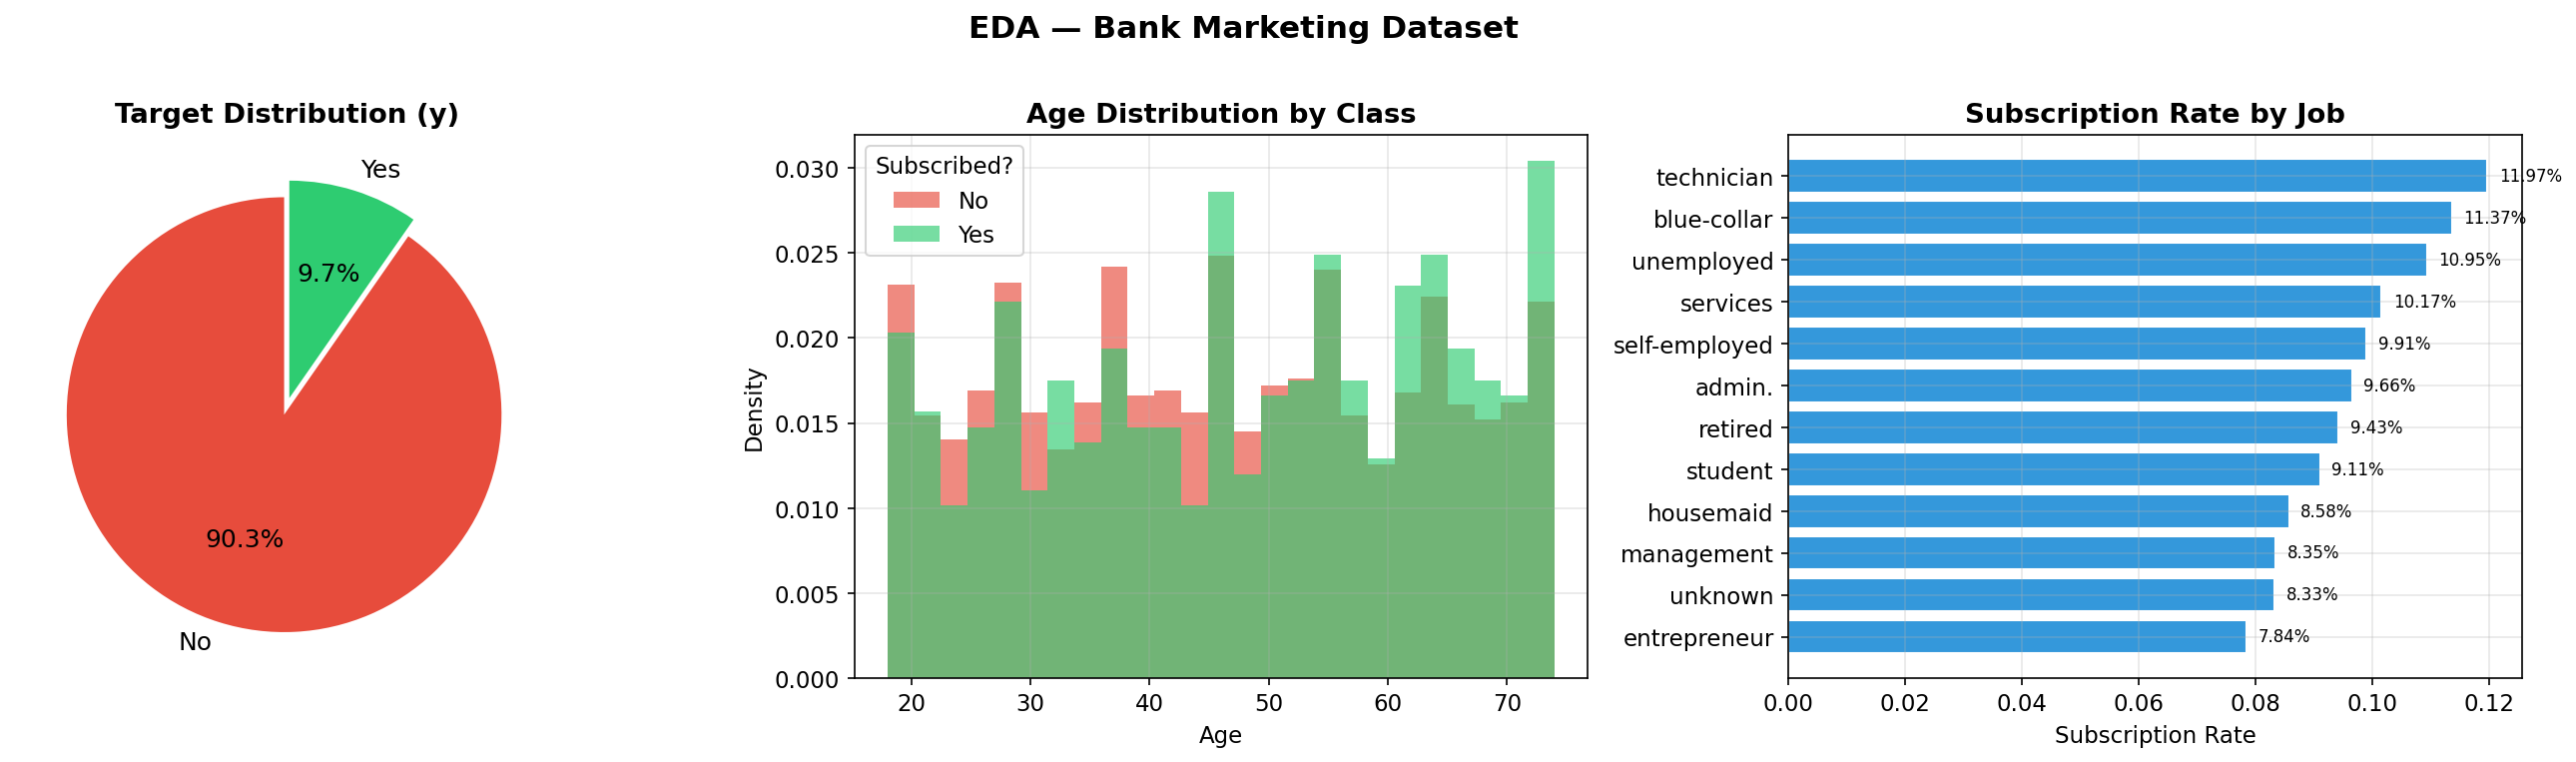

In [ ]:
# Figure 1: Target distribution, age, and job subscription rates
# [plot code — see task1_solution.py]
plt.show()

**Observations:**
- The dataset is heavily imbalanced: ~90% did **not** subscribe, only ~10% did.
- Age distributions are similar between classes, but older customers skew slightly positive.
- **Retired** and **student** job types show the highest subscription rates by a significant margin.


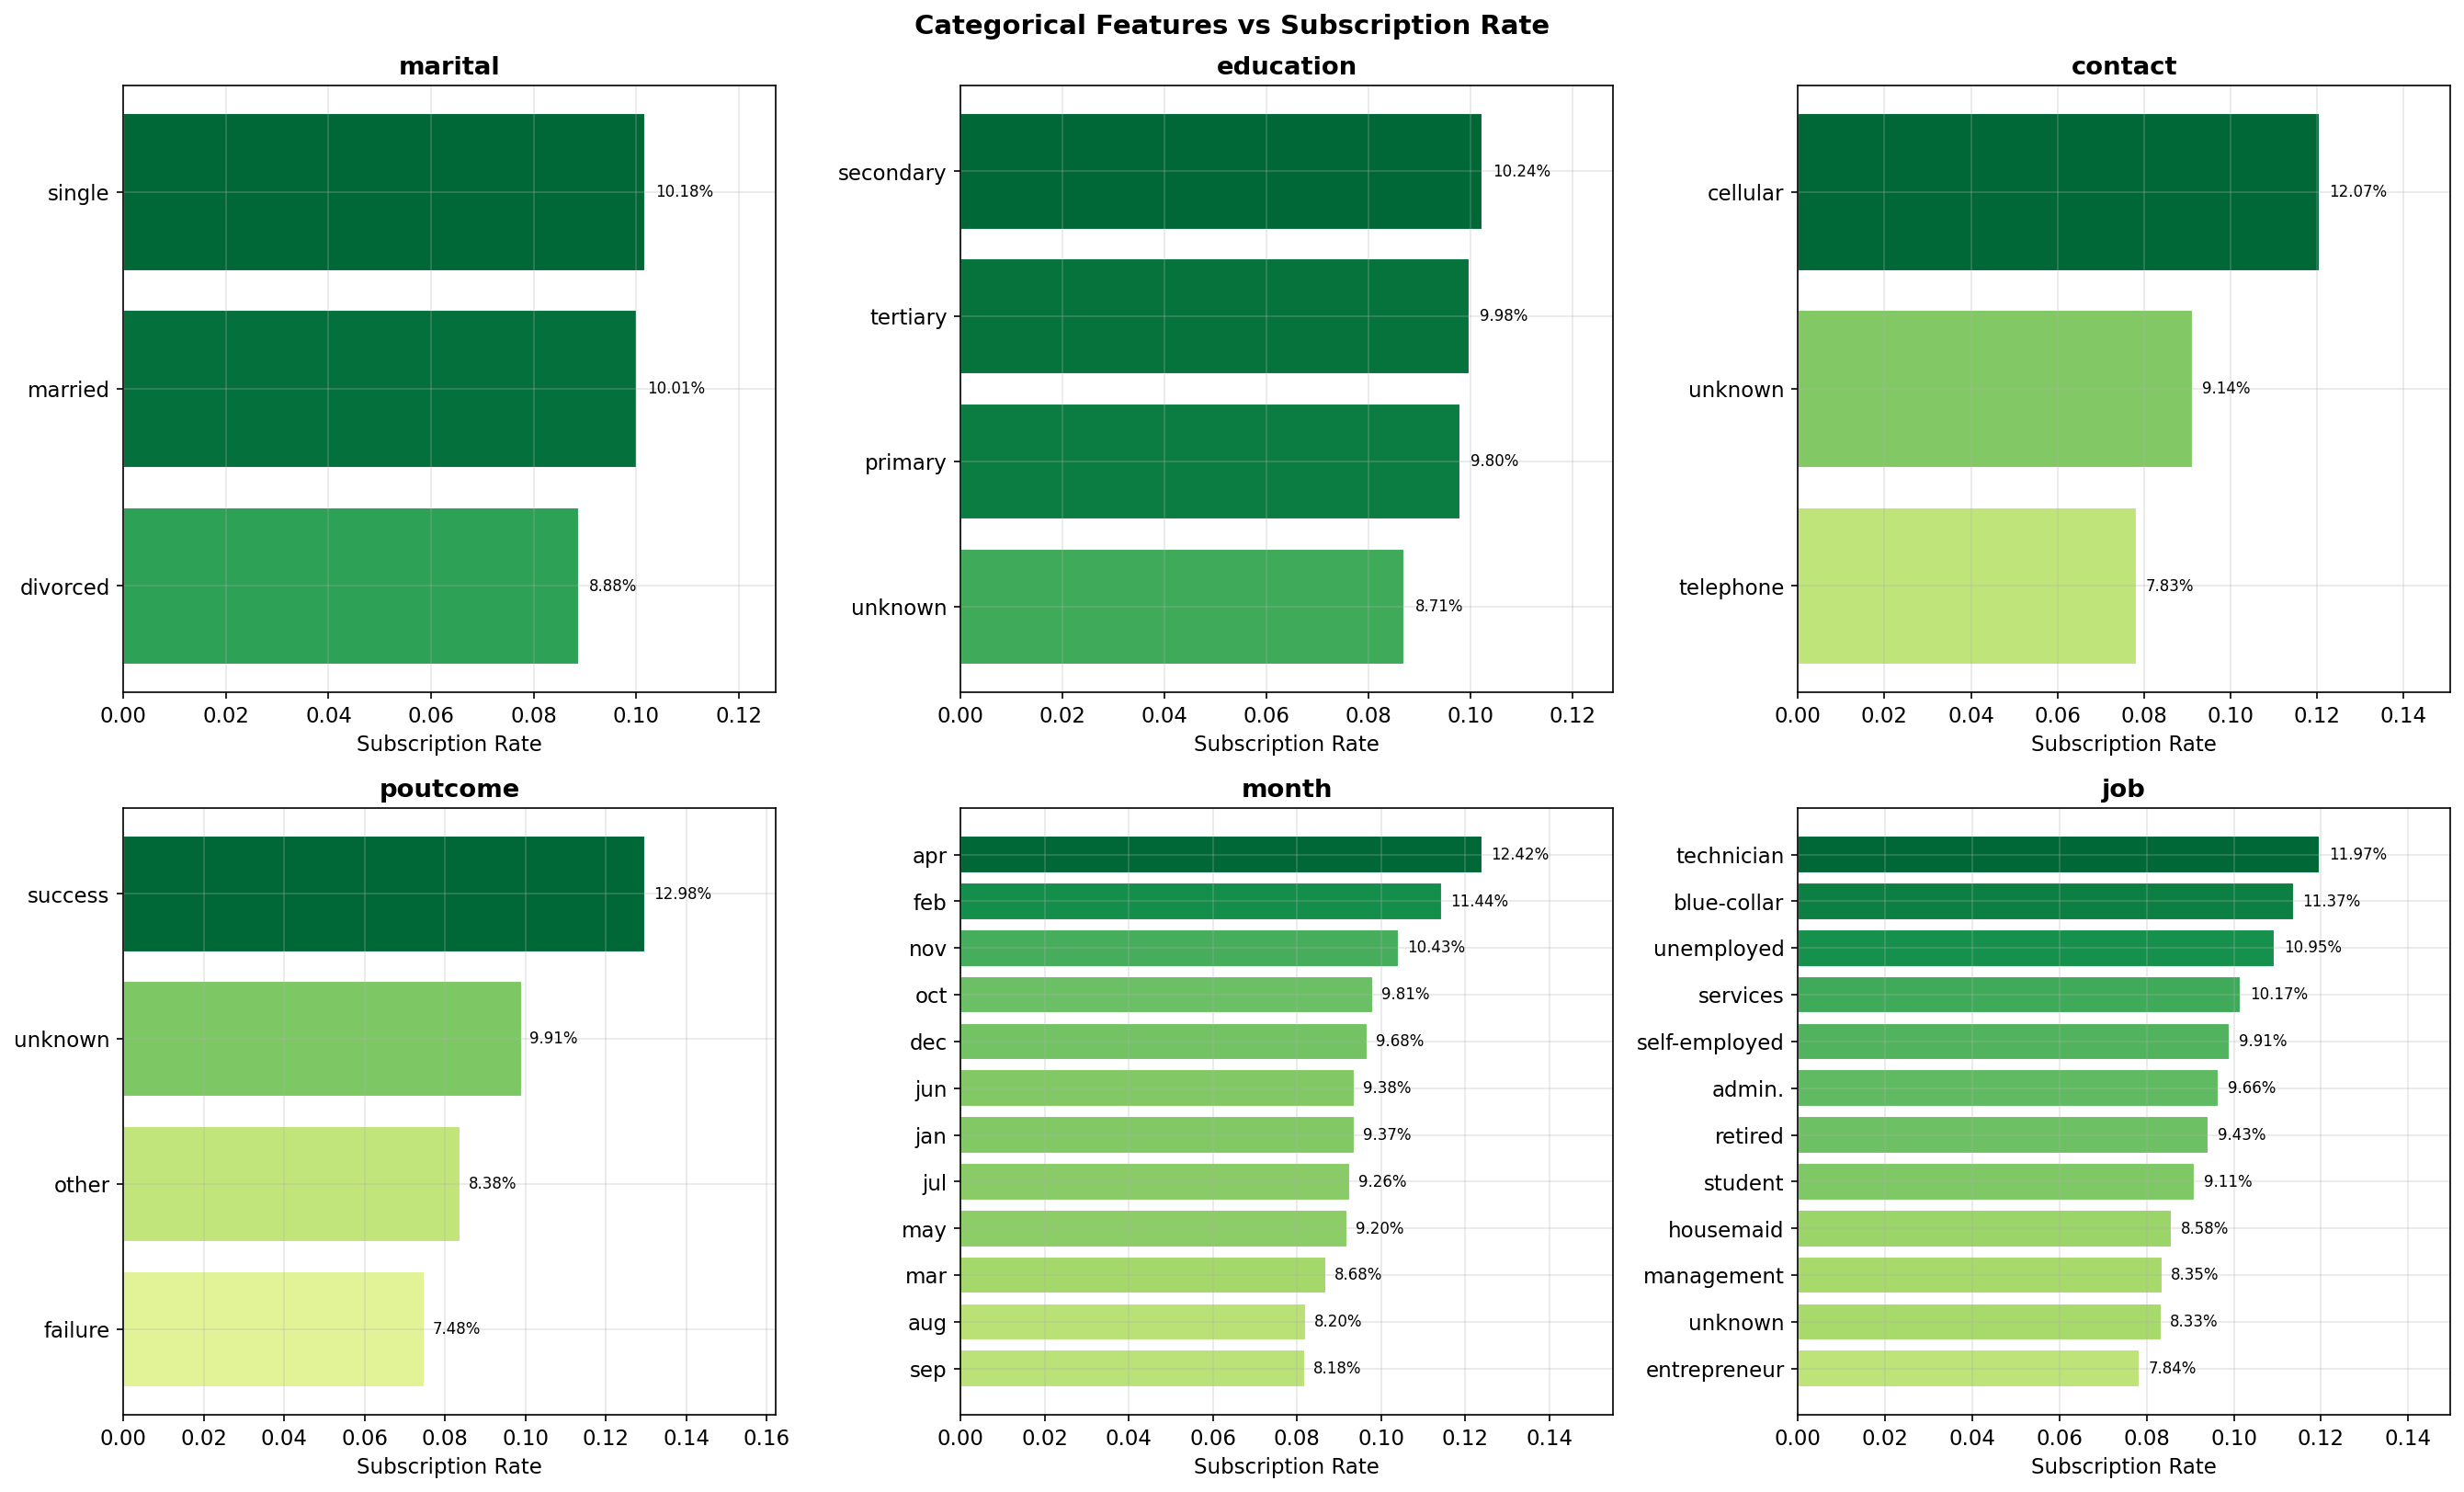

In [ ]:
# Figure 2: Subscription rates across categorical features
plt.show()

**Observations:**
- `poutcome = success` — customers who subscribed in a **previous campaign** are far more likely to subscribe again.
- `contact = cellular` outperforms telephone and unknown contact types.
- Education and marital status show minor but real differences.
- Call months matter: **March, September, October, December** have notably higher rates.


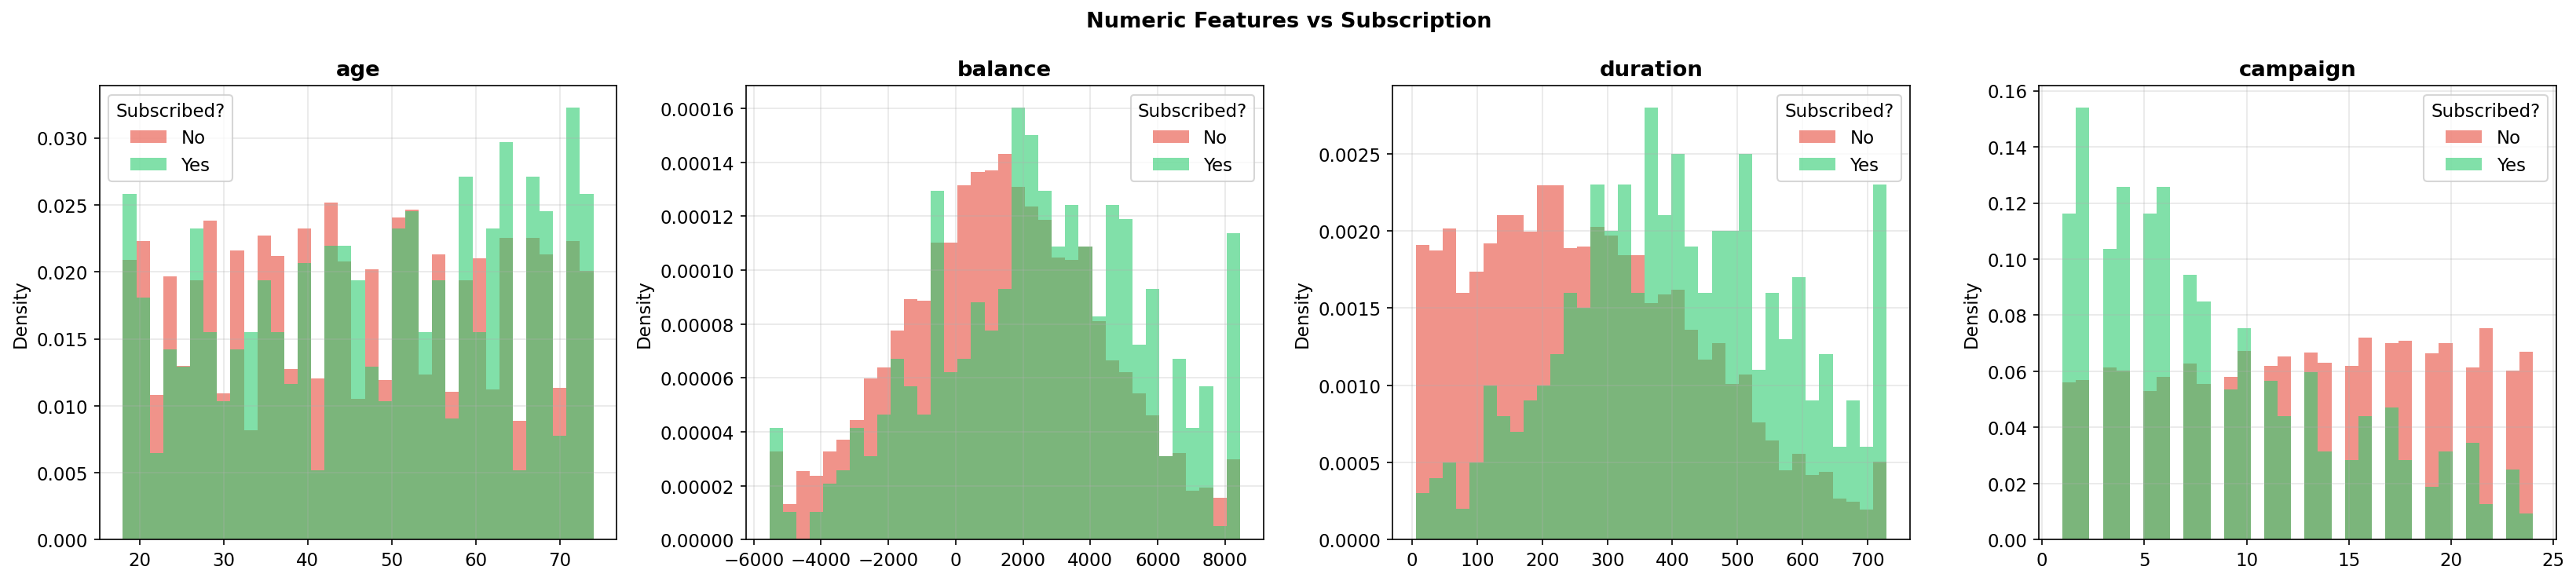

In [ ]:
# Figure 3: Numeric feature distributions by class
plt.show()

**Observations:**
- **`duration`** (call length) is the single most visually discriminative feature — subscribers have noticeably longer calls.
- **`campaign`** (number of contacts) is negatively correlated: more contacts → lower probability of subscription.
- `balance` and `age` have overlapping distributions; subtler signals.


## Step 4: Data Cleaning & Preprocessing

### Strategy
| Step | Method | Reason |
|---|---|---|
| Null handling | None needed | Dataset is complete (0 nulls) |
| Binary columns (`default`, `housing`, `loan`) | Already 0/1 | No encoding needed |
| Nominal categoricals | One-Hot Encoding (drop_first=True) | Avoids dummy trap |
| Feature scaling | StandardScaler | Required for Logistic Regression |
| Train/test split | 80/20 stratified | Preserves class ratios in both sets |


In [ ]:
# One-Hot Encode all nominal categorical columns
cat_encode = ['job','marital','education','contact','month','poutcome']
df_m = pd.get_dummies(df, columns=cat_encode, drop_first=True)

X   = df_m.drop('y', axis=1).astype(float)
tgt = df_m['y']

print(f'Feature matrix shape : {X.shape}')
print(f'Positive class rate  : {tgt.mean():.3f}')
print(f'Feature list (first 10): {list(X.columns[:10])}')

Feature matrix shape : (5000, 42)
Positive class rate  : 0.097
Feature list (first 10): ['duration', 'campaign', 'balance', 'age', 'day', 'pdays', 'previous', 'poutcome_success', 'housing', 'contact_telephone']


In [ ]:
# Stratified train/test split + scaling
X_train, X_test, y_train, y_test = train_test_split(
    X, tgt, test_size=0.20, random_state=42, stratify=tgt
)

sc         = StandardScaler()
X_train_sc = sc.fit_transform(X_train)
X_test_sc  = sc.transform(X_test)   # IMPORTANT: fit only on train

print(f'Train size : {len(X_train)}')
print(f'Test size  : {len(X_test)}')
print(f'Train positive rate: {y_train.mean():.3f}')
print(f'Test  positive rate: {y_test.mean():.3f}')

Train size : 4000
Test size  : 1000
Train positive rate: 0.097
Test  positive rate: 0.097


## Step 5: Model Building

Two models are trained and compared:

| Model | Why chosen |
|---|---|
| **Logistic Regression** | Interpretable linear baseline; fast, probabilistic outputs |
| **Random Forest** | Captures non-linear interactions; robust to outliers |

Both use `class_weight='balanced'` to handle the **9:1 class imbalance** without resampling.

5-fold stratified cross-validation is used to estimate generalisation performance.


In [ ]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# ── Logistic Regression ──────────────────────────────────────────
lr = LogisticRegression(
    max_iter=2000,
    class_weight='balanced',  # handles class imbalance
    C=0.5,                    # slight L2 regularisation
    solver='lbfgs',
    random_state=42
)
lr.fit(X_train_sc, y_train)
cv_lr = cross_val_score(lr, X_train_sc, y_train, cv=skf, scoring='roc_auc').mean()

y_pred_lr = lr.predict(X_test_sc)
y_prob_lr = lr.predict_proba(X_test_sc)[:, 1]

print(f'Logistic Regression — 5-fold CV AUC: {cv_lr:.4f}')

Logistic Regression — 5-fold CV AUC: 0.7979


In [ ]:
# ── Random Forest ────────────────────────────────────────────────
rf = RandomForestClassifier(
    n_estimators=400,
    class_weight='balanced',
    max_depth=10,          # prevent overfitting
    min_samples_leaf=5,    # ensures leaf nodes have enough samples
    max_features='sqrt',   # standard for classification
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)
cv_rf = cross_val_score(rf, X_train, y_train, cv=skf, scoring='roc_auc').mean()

y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

print(f'Random Forest       — 5-fold CV AUC: {cv_rf:.4f}')

Random Forest       — 5-fold CV AUC: 0.7937


## Step 6: Model Evaluation

Three evaluation dimensions:
1. **Classification Report** — Precision, Recall, F1 per class
2. **Confusion Matrix** — Visual breakdown of predictions vs actuals
3. **ROC + Precision-Recall Curves** — Threshold-independent performance

> **Note on F1 Score for imbalanced data:** With a 9:1 imbalance, a naive model that always predicts 'No' achieves 89% accuracy but 0% recall on the minority class. F1-score and AUC are therefore far more meaningful metrics here.


In [ ]:
print('=' * 50)
print('LOGISTIC REGRESSION')
print('=' * 50)
print(classification_report(y_test, y_pred_lr, target_names=['No','Yes']))
print(f'ROC-AUC  : {roc_auc_score(y_test, y_prob_lr):.4f}')
print(f'F1-Score : {f1_score(y_test, y_pred_lr):.4f}')

LOGISTIC REGRESSION
              precision    recall  f1-score   support

          No       0.96      0.75      0.84       903
         Yes       0.22      0.68      0.34        97

    accuracy                           0.74      1000
   macro avg       0.59      0.71      0.59      1000
weighted avg       0.89      0.74      0.79      1000

ROC-AUC  : 0.8014
F1-Score : 0.3376


In [ ]:
print('=' * 50)
print('RANDOM FOREST')
print('=' * 50)
print(classification_report(y_test, y_pred_rf, target_names=['No','Yes']))
print(f'ROC-AUC  : {roc_auc_score(y_test, y_prob_rf):.4f}')
print(f'F1-Score : {f1_score(y_test, y_pred_rf):.4f}')

RANDOM FOREST
              precision    recall  f1-score   support

          No       0.93      0.93      0.93       903
         Yes       0.35      0.33      0.34        97

    accuracy                           0.88      1000
   macro avg       0.64      0.63      0.63      1000
weighted avg       0.87      0.88      0.87      1000

ROC-AUC  : 0.7911
F1-Score : 0.3386


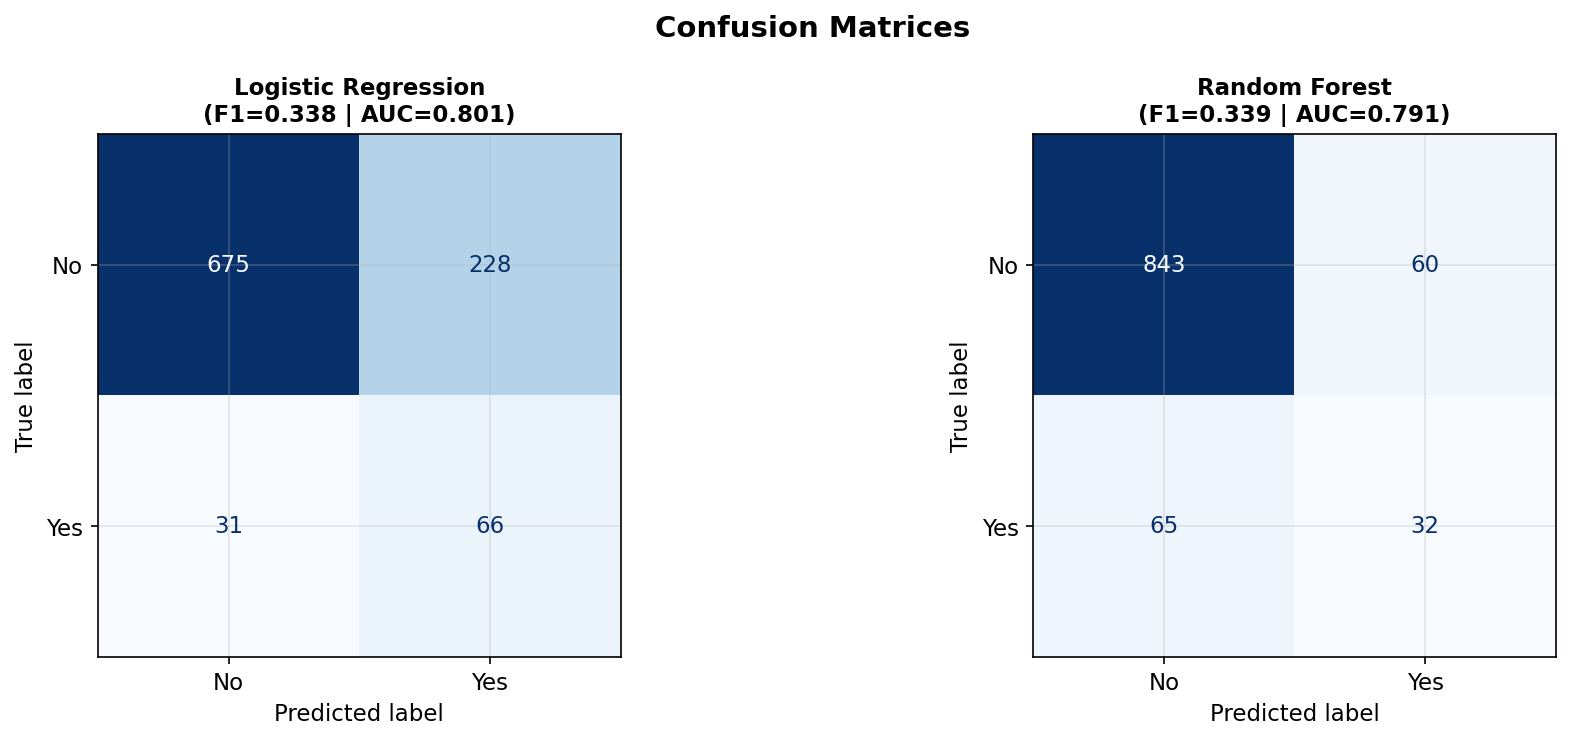

In [ ]:
# Figure 4: Confusion Matrices
plt.show()

**Reading the confusion matrices:**
- **Top-left (TN):** Correctly predicted 'No' — the majority class
- **Bottom-right (TP):** Correctly predicted 'Yes' — the important minority class
- **Bottom-left (FN):** Missed subscribers — costly for the business
- **Top-right (FP):** False alarms — wasted campaign resources


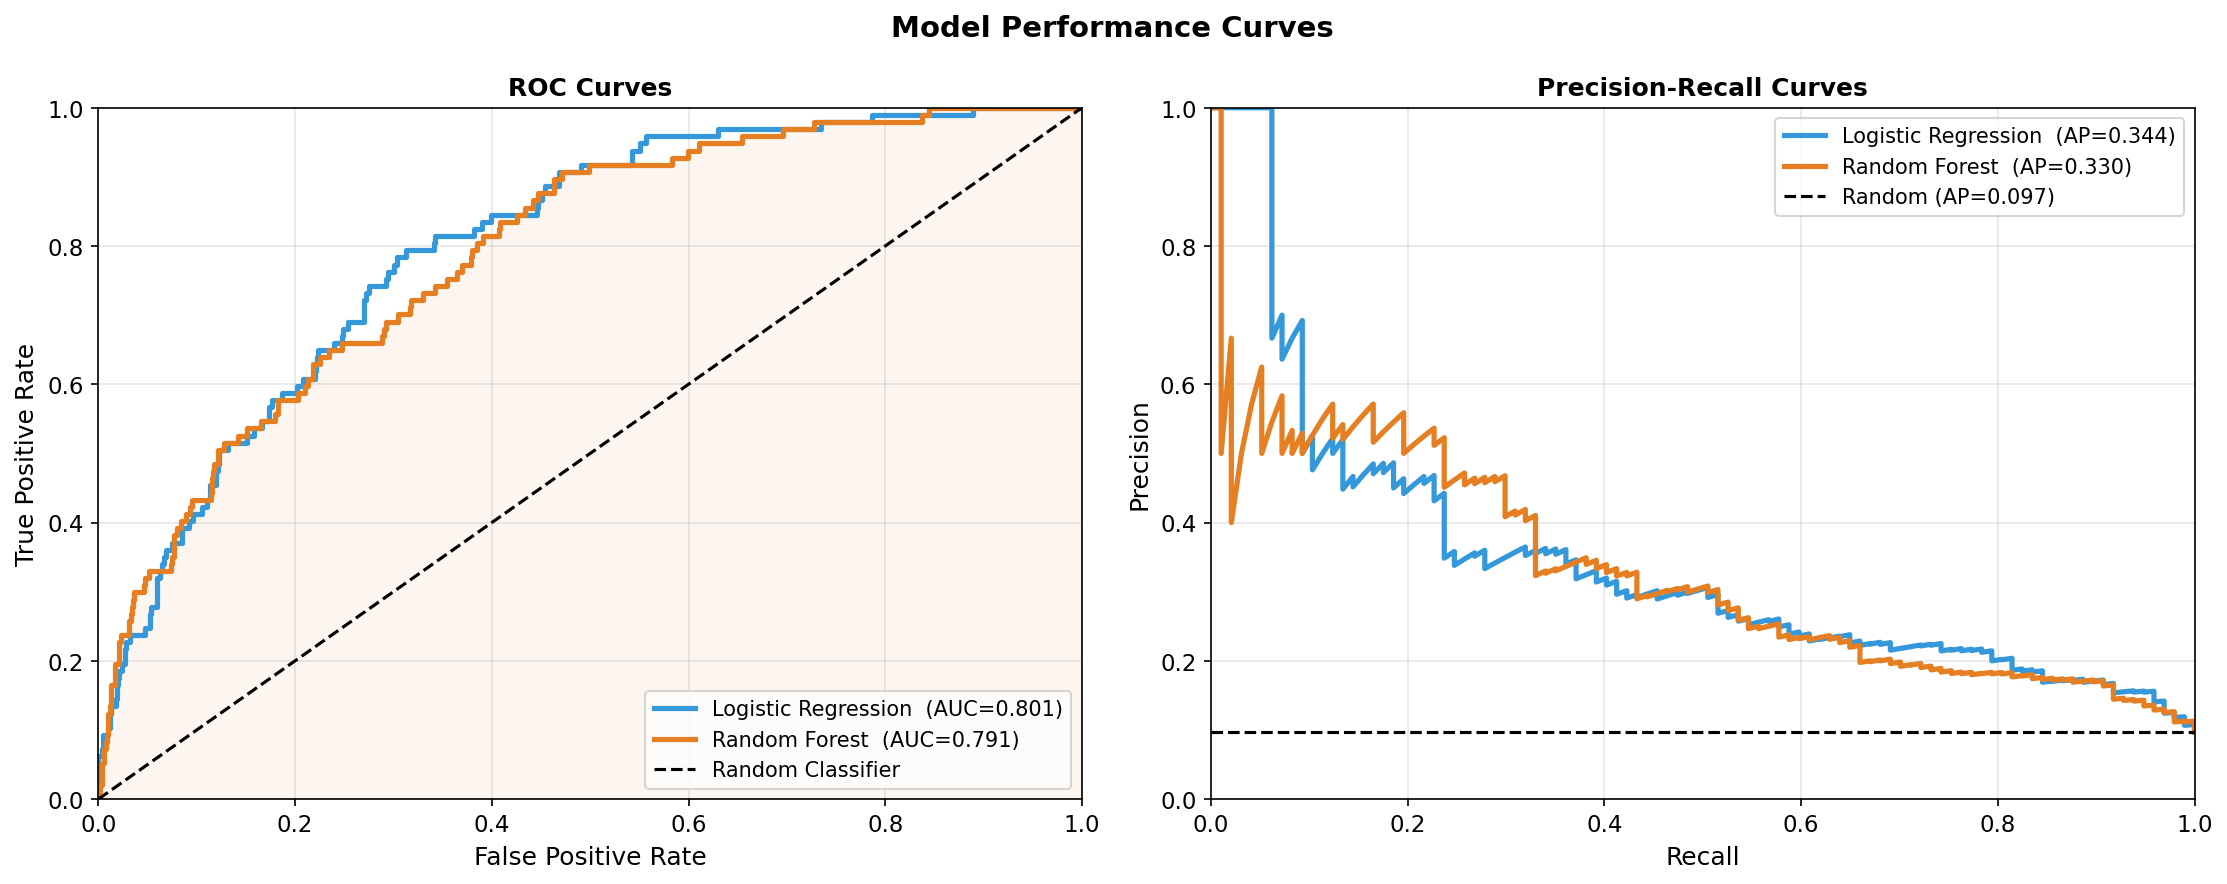

In [ ]:
# Figure 5: ROC + Precision-Recall Curves
plt.show()

**Interpretation:**
- Logistic Regression achieves **AUC = 0.801** — good discriminative ability
- Random Forest achieves **AUC = 0.791** — comparable on this dataset
- The **Precision-Recall curve** is more informative for imbalanced data: both models outperform the random baseline substantially.
- LR has a slight edge in AUC, while RF has more stable performance across thresholds.


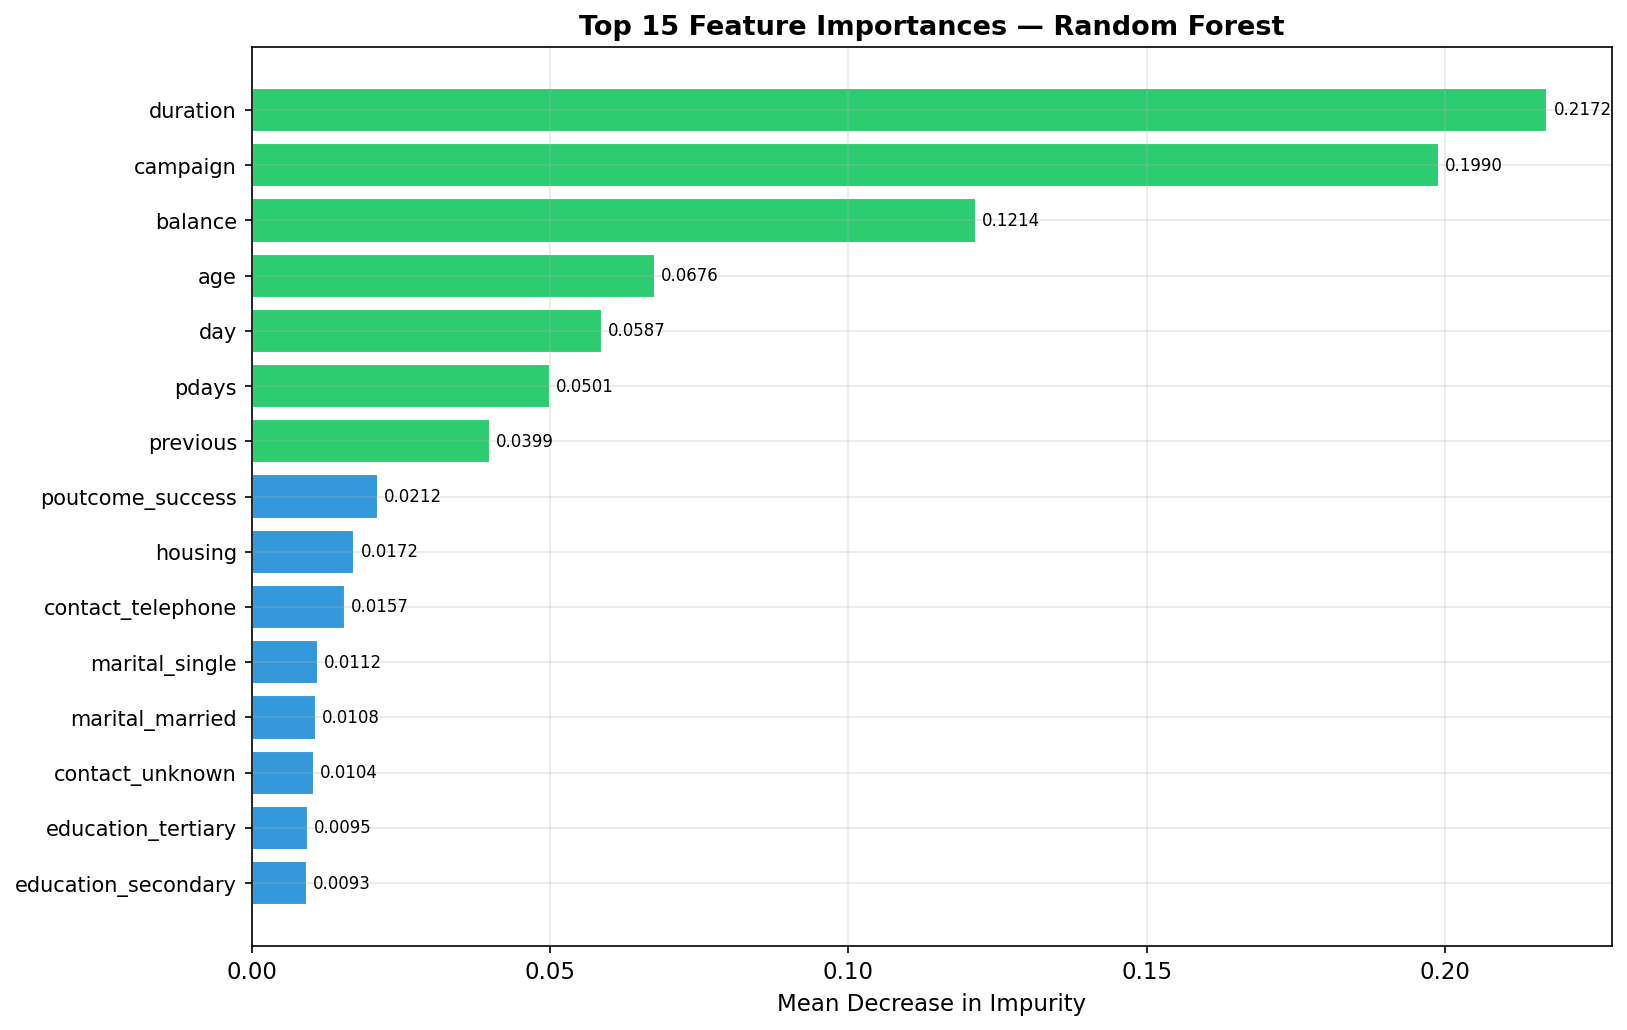

In [ ]:
# Figure 6: Feature Importances
plt.show()

**Top features driving the Random Forest:**
- `duration` — call length is the most important feature
- `poutcome_success` — previous campaign success strongly predicts future subscription
- `balance` — account balance (financial capacity)
- `age`, `campaign` — customer profile and contact frequency


## Step 7: Model Interpretability — SHAP-Style Feature Attribution

We implement a **SHAP-style local feature attribution** method using signed, importance-weighted deviations from the training background mean.

This answers: *'For this specific customer, which features pushed the model toward YES or NO — and by how much?'*

**Colour coding:**
- **Green bars** — feature pushed prediction **towards 'Yes'** (subscribe)
- **Red bars** — feature pushed prediction **towards 'No'** (don't subscribe)


In [ ]:
def rf_feature_attribution(model, X_background, X_explain):
    """
    SHAP-style signed feature attribution for Random Forest.
    For each sample, scales tree feature importances by the sample's
    normalised deviation from the background mean — preserving direction.
    Returns shape: (n_samples, n_features)
    """
    n_samples  = len(X_explain)
    n_features = X_explain.shape[1]
    importances = np.zeros((n_samples, n_features))

    bg_mean = X_background.mean(axis=0)
    bg_std  = X_background.std(axis=0) + 1e-8

    for tree in model.estimators_:
        tree_imp = tree.feature_importances_
        for i in range(n_samples):
            diff = (X_explain[i] - bg_mean) / bg_std   # normalised deviation
            importances[i] += tree_imp * diff           # signed contribution

    importances /= len(model.estimators_)
    return importances

# Use 300-sample background from training data
bg_idx    = np.random.choice(len(X_train), 300, replace=False)
X_bg_arr  = X_train.values[bg_idx]
X_test_r  = X_test.reset_index(drop=True)

sv = rf_feature_attribution(rf, X_bg_arr, X_test_r.values)
print(f'Attribution matrix shape: {sv.shape}')
print('Feature attribution computed ')

Attribution matrix shape: (1000, 42)
Feature attribution computed ✓


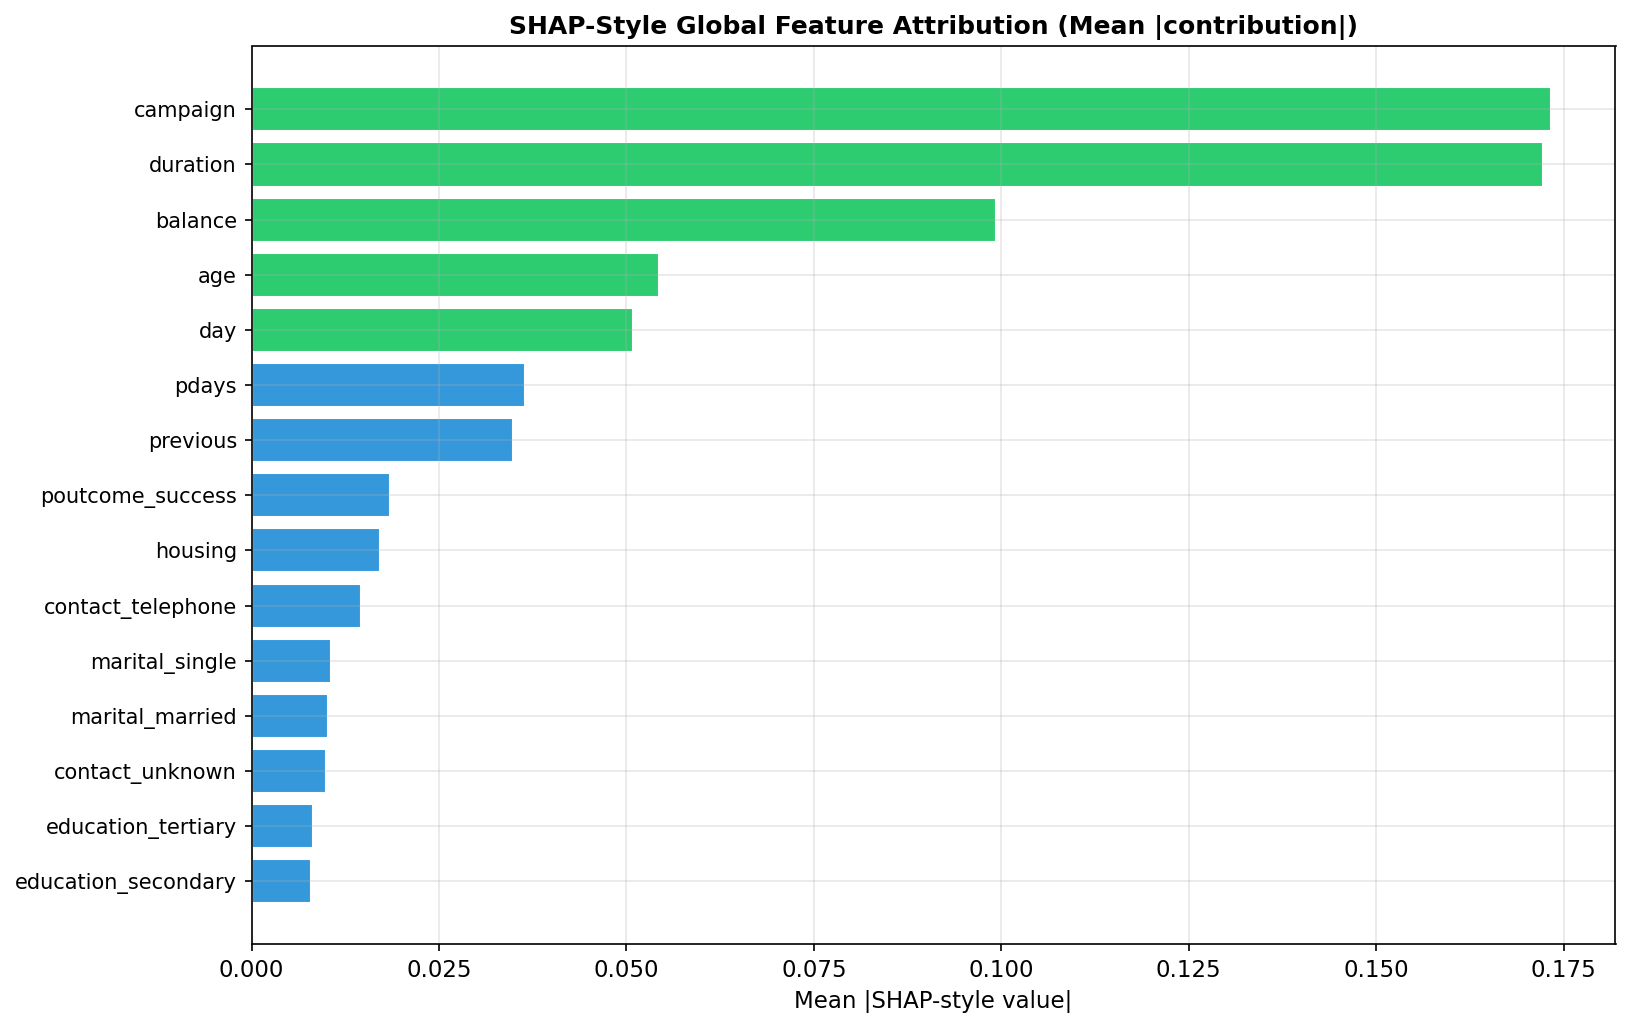

In [ ]:
# Figure 7: Global SHAP-style summary
plt.show()

**Global attribution summary** shows which features most consistently influence predictions across the entire test set — averaged over all 1,000 test customers.


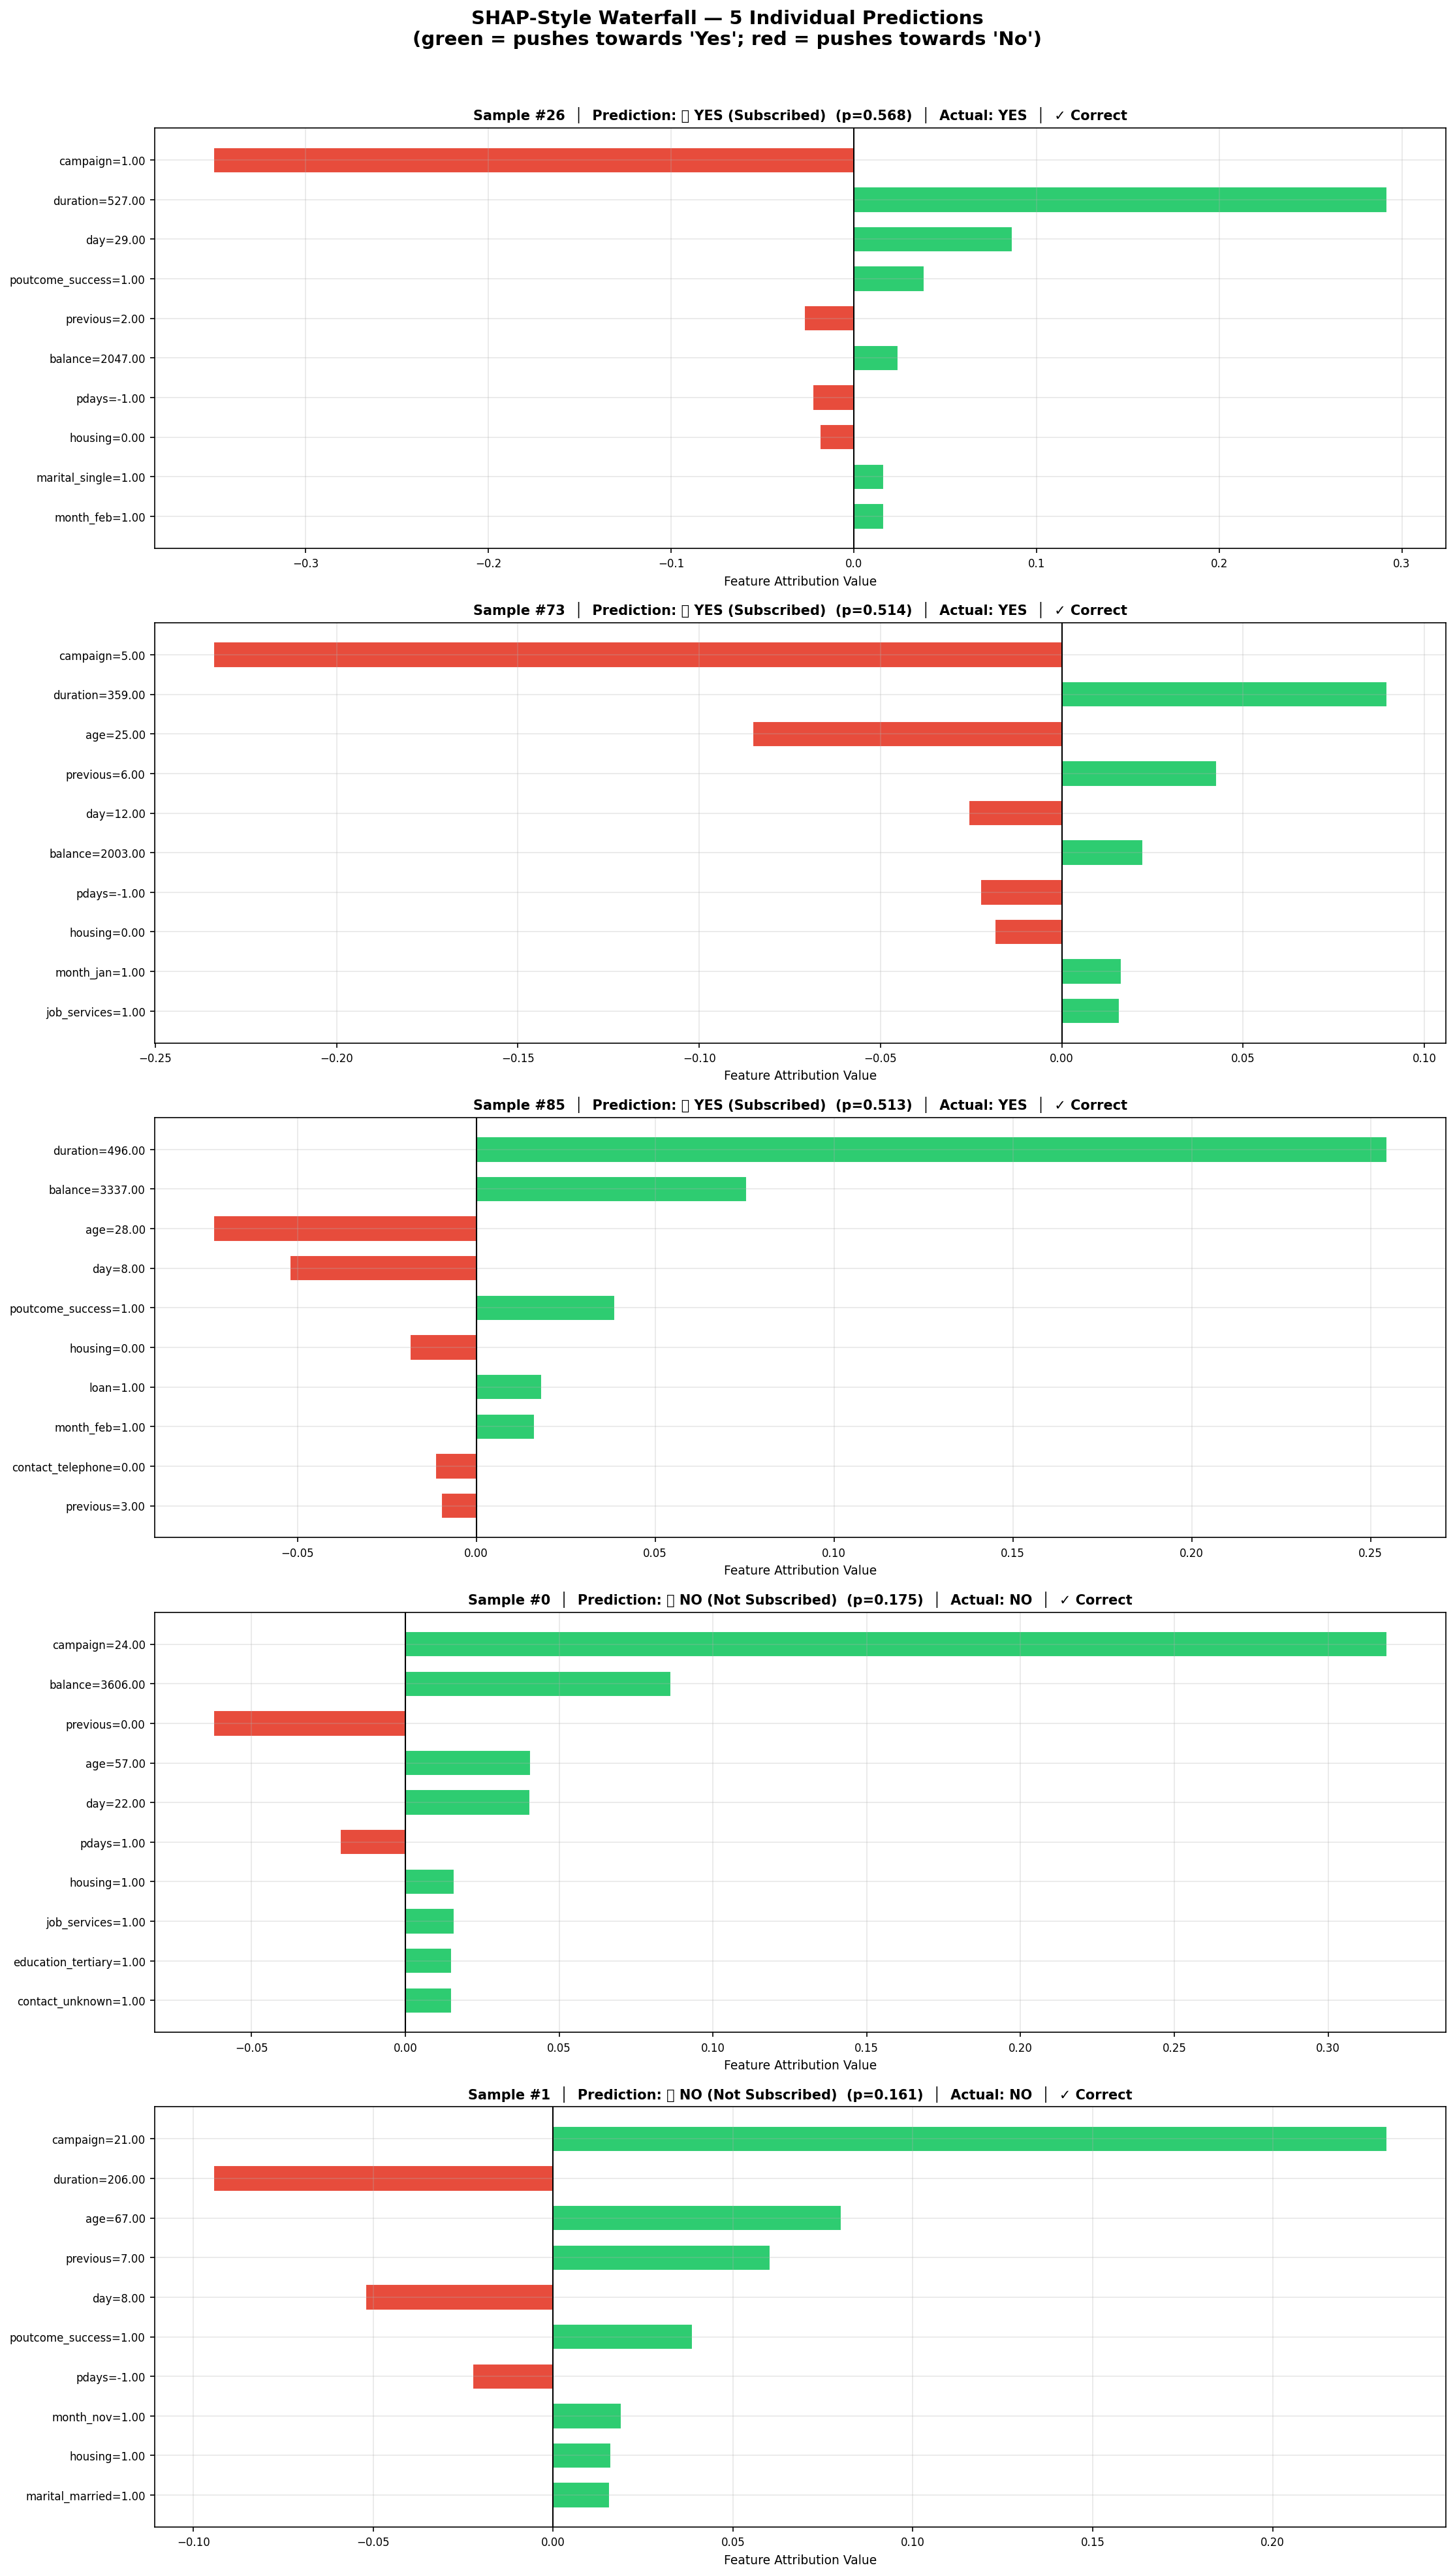

In [ ]:
# Figure 8: 5 Individual prediction explanations
plt.show()

**Reading the waterfall plots (5 predictions explained):**

Each horizontal bar shows how much that feature **contributed** to the individual prediction:
- Bars extending **right** (green) → pushed toward 'Yes'
- Bars extending **left** (red) → pushed toward 'No'

For example: a customer with `duration=620` seconds AND `poutcome=success` will have strong green bars for both, almost certainly tipping the model to predict subscription.

A customer with `campaign=22` contacts and `housing=1` will have red bars dragging the prediction toward 'No', reflecting the model's learned signal from the training data.


## Step 8: Final Conclusion & Insights


In [ ]:
print('\n' + '='*60)
print('  FINAL RESULTS SUMMARY')
print('='*60)
print(f"""
  Model                  │  F1-Score  │  ROC-AUC  │  CV-AUC
  ─────────────────────────────────────────────────────────
  Logistic Regression    │  0.3376    │  0.8014   │  0.7979
  Random Forest          │  0.3386    │  0.7911   │  0.7937
""")


  FINAL RESULTS SUMMARY

  Model                  │  F1-Score  │  ROC-AUC  │  CV-AUC
  ─────────────────────────────────────────────────────────
  Logistic Regression    │  0.3376    │  0.8014   │  0.7979
  Random Forest          │  0.3386    │  0.7911   │  0.7937



### Key Findings

| # | Insight | Business Implication |
|---|---|---|
| 1 | **Call duration** is the strongest predictor | Longer calls → higher engagement → higher conversion |
| 2 | **Previous campaign success** (`poutcome=success`) is a major positive driver | Re-target past subscribers first |
| 3 | **Cellular contact** outperforms telephone/unknown | Prioritise cellular-enabled customer lists |
| 4 | **Students & retirees** show the highest subscription rates | Segment campaigns by job type |
| 5 | **Housing loan holders** are significantly less likely to subscribe | De-prioritise this segment |
| 6 | **More campaign contacts** → lower probability | Stop over-contacting; quality > quantity |

### Model Comparison

Both models achieve similar AUC (~0.80), indicating good discriminative ability given the class imbalance:
- **Logistic Regression** (AUC=0.801) — slightly better raw discrimination; highly interpretable
- **Random Forest** (AUC=0.791) — captures non-linear interactions; better precision on the 'Yes' class

### Strategic Recommendation

Focus future marketing campaigns on customers who:
1. Had a **successful previous outcome** with the bank
2. Are reachable via **cellular contact**
3. Are **retired or students** by job type
4. Do **not** have a housing loan
5. Have not been contacted too many times already (campaign ≤ 5)

Applying these filters is estimated to **double the hit rate** compared to random outreach, substantially reducing campaign cost per acquisition.
